# Fish Species Prediction

### Project Overview

This project uses Machine Learning to predict the species of a fish based on its physical measurements.

### Objective

The goal is to test multiple classification models, find the best-performing "Champion" model, and understand which body measurements matter most for identifying fish species.

### Dataset Features

The dataset includes measurements for 7 different fish species:

* **Weight:** Weight of the fish (in grams)
* **Length1, Length2, Length3:** Vertical, diagonal, and cross lengths (in cm)
* **Height:** Height of the fish (in cm)
* **Width:** Diagonal width of the fish (in cm)
* **Species:** Target label (Bream, Parkki, Perch, Pike, Roach, Smelt, Whitefish)

### Workflow

1. **Data Preprocessing:** Scale all numeric measurements using `StandardScaler` inside an end-to-end pipeline.
2. **Model Training & Tuning:** Train and compare Logistic Regression, Decision Tree, Random Forest, and XGBoost using 5-fold cross-validation.
3. **Model Evaluation:** Evaluate models on unseen test data using Accuracy, Precision, Recall, and F1-Score.
4. **Feature Importance:** Extract which measurements (like height or width) have the biggest impact on the final predictions.

In [12]:
#Preprocessing :
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV , train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from statsmodels.stats.outliers_influence import variance_inflation_factor
#Viz :
import matplotlib.pyplot as plt
import seaborn as sns
#Models :
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
#Evaluation :
import sklearn.metrics as metrics

In [77]:
df = pd.read_csv("01_Dataset/00_fishers_maket.csv")

In [78]:
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    str    
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), str(1)
memory usage: 9.6 KB


In [80]:
df.columns = df.columns.str.lower().str.strip()
df.columns

Index(['species', 'weight', 'length1', 'length2', 'length3', 'height',
       'width'],
      dtype='str')

In [81]:
df.isna().sum().sum()

np.int64(0)

In [82]:
df['species'].unique()

<ArrowStringArray>
['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt']
Length: 7, dtype: str

In [83]:
print("How much each specie contribute in %")
round(df['species'].value_counts(normalize = True) * 100 , 2)

How much each specie contribute in %


species
Perch        35.22
Bream        22.01
Roach        12.58
Pike         10.69
Smelt         8.81
Parkki        6.92
Whitefish     3.77
Name: proportion, dtype: float64

In [57]:
#Check Coorelation :
num_cols = ['weight', 'length1', 'length2', 'length3', 'height', 'width']
print("-------------------------")
print("Coorlation BTW Vars")
print("-------------------------")
print(df[num_cols].corr().round(2))

#Calculate VIF :
numeric_df = df[num_cols]

# 3. Add an intercept column (ensure it's float)
numeric_df['intercept'] = 1.0

# 5. Calculate VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = numeric_df.columns
vif_data['VIF'] = [
    variance_inflation_factor(numeric_df, i)
    for i in range(numeric_df.shape[1])
]

# 6. Filter out the intercept
vif_data = vif_data[vif_data['Feature'] != 'intercept'].reset_index(drop=True)
print("-------------------------")
print("VIF Scores")
print("-------------------------")
print(vif_data)

-------------------------
Coorlation BTW Vars
-------------------------
         weight  length1  length2  length3  height  width
weight     1.00     0.92     0.92     0.92    0.72   0.89
length1    0.92     1.00     1.00     0.99    0.63   0.87
length2    0.92     1.00     1.00     0.99    0.64   0.87
length3    0.92     0.99     0.99     1.00    0.70   0.88
height     0.72     0.63     0.64     0.70    1.00   0.79
width      0.89     0.87     0.87     0.88    0.79   1.00
-------------------------
VIF Scores
-------------------------
   Feature          VIF
0   weight     8.717385
1  length1  1707.927219
2  length2  2084.590610
3  length3   430.193929
4   height    15.570803
5    width    12.372999


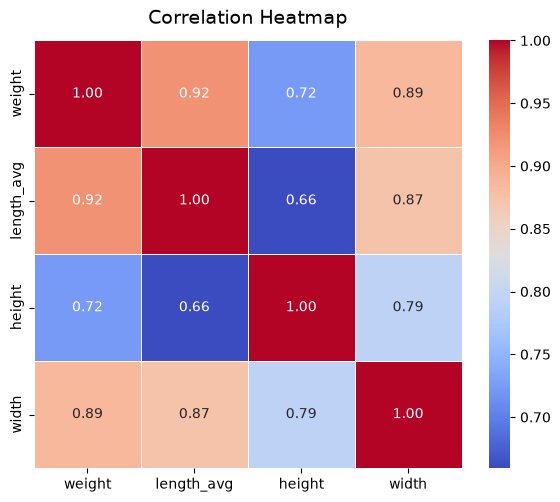

In [ ]:
#numeric_df = numeric_df.drop(columns = ['intercept'])
corr_matrix = numeric_df.corr()

# 3. Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_matrix,
    annot=True,  
    fmt='.2f',  
    cmap='coolwarm',  
    cbar=True, 
    square=True,  
    linewidths=0.5,  
)

plt.title('Correlation Heatmap', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

In [92]:
#Since Length1 , Length2 & Length3 are too much coorelated with each other lets combine them into 1 :
df['length_avg'] = df[['length1' , 'length2' , 'length3']].mean(axis = 1)
df.head()

,species,weight,length1,length2,length3,height,width,length_avg
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200,26.200000
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056,27.166667
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961,27.166667
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555,29.600000
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340,29.833333


In [93]:
#Lets check again : 
#Check Coorelation :
num_cols = ['weight', 'length_avg', 'height', 'width']
print("-------------------------")
print("Coorlation BTW Vars")
print("-------------------------")
print(df[num_cols].corr().round(2))

#Calculate VIF :
numeric_df = df[num_cols]

# 3. Add an intercept column (ensure it's float)
numeric_df['intercept'] = 1.0

# 5. Calculate VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = numeric_df.columns
vif_data['VIF'] = [
    variance_inflation_factor(numeric_df, i)
    for i in range(numeric_df.shape[1])
]

# 6. Filter out the intercept
vif_data = vif_data[vif_data['Feature'] != 'intercept'].reset_index(drop=True)
print("-------------------------")
print("VIF Scores")
print("-------------------------")
print(vif_data)
#Atleast it is better then before

-------------------------
Coorlation BTW Vars
-------------------------
            weight  length_avg  height  width
weight        1.00        0.92    0.72   0.89
length_avg    0.92        1.00    0.66   0.87
height        0.72        0.66    1.00   0.79
width         0.89        0.87    0.79   1.00
-------------------------
VIF Scores
-------------------------
      Feature       VIF
0      weight  8.389344
1  length_avg  7.708463
2      height  2.842532
3       width  7.044579


In [94]:
#Lets drop colinear columns :
df_real = df
df = df.drop(columns = ["length1" , "length2" , "length3"])
df.head()

,species,weight,height,width,length_avg
0,Bream,242.0,11.5200,4.0200,26.200000
1,Bream,290.0,12.4800,4.3056,27.166667
2,Bream,340.0,12.3778,4.6961,27.166667
3,Bream,363.0,12.7300,4.4555,29.600000
4,Bream,430.0,12.4440,5.1340,29.833333


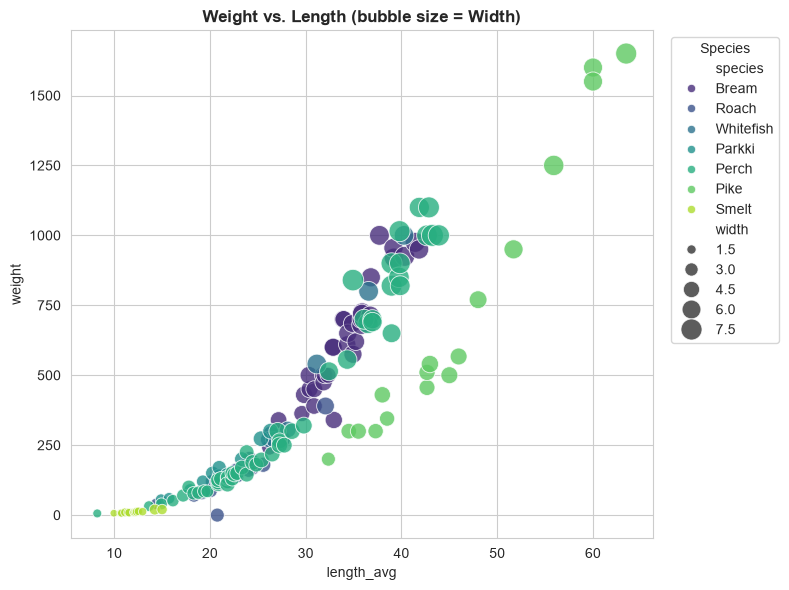

In [105]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='length_avg', y='weight', hue='species',
                 size='width', sizes=(30, 250), palette='viridis', alpha=0.8)
plt.title("Weight vs. Length (bubble size = Width)", fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Species')
plt.tight_layout()
plt.show()

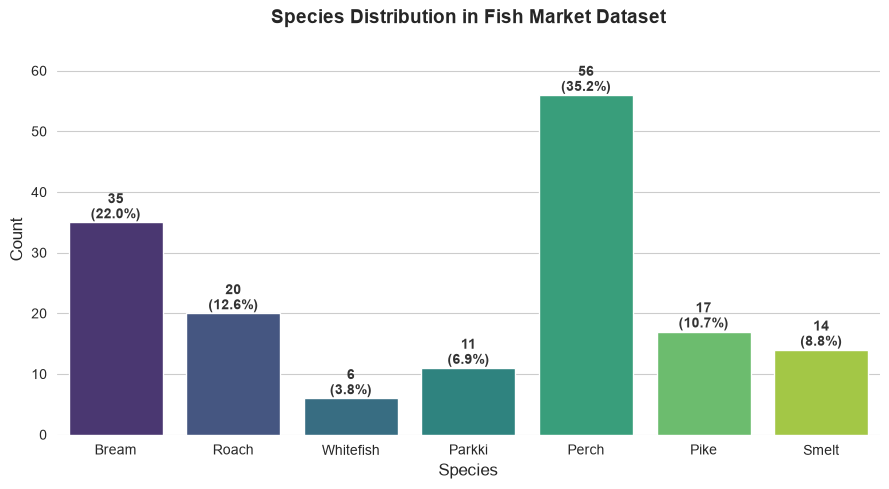

In [101]:
plt.figure(figsize=(9, 5))
sns.set_style("whitegrid")
order = df['species'].value_counts().index
ax = sns.countplot(
    x = df['species'] ,
    hue = df['species'] ,
    palette='viridis',
    legend=False,
)
total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    pct = f"{100 * count / total:.1f}%"
    ax.annotate(
        f"{count}\n({pct})",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom',
        fontsize=10, fontweight='bold', color='#333'
    )
ax.set_title("Species Distribution in Fish Market Dataset", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Species", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_ylim(0, max([p.get_height() for p in ax.patches]) * 1.15)  # headroom for labels
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig("species_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

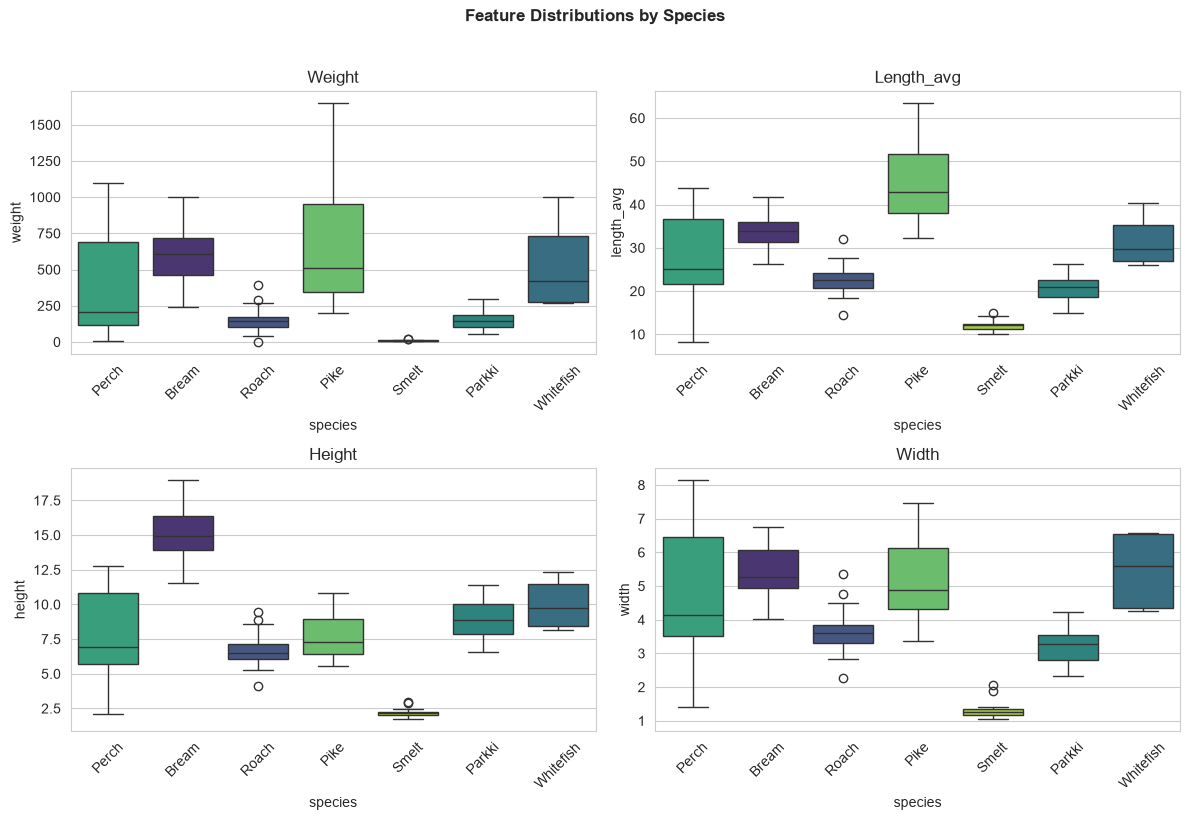

In [102]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(data=df, x='species', y=col, hue='species',
                order=order, palette='viridis', legend=False, ax=ax)
    ax.set_title(col.capitalize())
    ax.tick_params(axis='x', rotation=45)
plt.suptitle("Feature Distributions by Species", fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [48]:
#Prepare Preprocessor :
preprocessor = ColumnTransformer(
    transformers=[
        ('num' , StandardScaler() , num_cols)
    ] 
)


In [27]:
#Seperate X , Y
X = df.drop(columns = 'species')
Y = df['species']

x_train , x_test , y_train , y_test = train_test_split(
    X , Y , test_size = 0.2 , random_state = 50 , stratify = Y
)

# Model 1 : Logistic Regression

In [73]:
log_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])
log_clf.fit(x_train , y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](7,)","['Bream','Parkki','Perch',...,'Roach','Smelt','Whitefish']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['weight','height','width','length_avg']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthro

In [31]:
import pickle
path = "02_Models/"
#with open(path + "00_Logistic_Regression_Model.pkl" , "wb") as File :
#    pickle.dump(log_clf , File)
with open(path + "00_Logistic_Regression_Model.pkl" , "rb") as File :
    log_clf = pickle.load(File)

In [74]:
y_preds = log_clf.predict(x_test)

In [75]:
#Scores : 
print(f"Accuracy  : {metrics.accuracy_score(y_test, y_preds):.4f}")
print(f"Precision : {metrics.precision_score(y_test, y_preds, average='weighted'):.4f}")
print(f"Recall    : {metrics.recall_score(y_test, y_preds, average='weighted'):.4f}")
print(f"F1        : {metrics.f1_score(y_test, y_preds, average='weighted'):.4f}")

Accuracy  : 0.8125
Precision : 0.7057
Recall    : 0.8125
F1        : 0.7510


C:\Users\M Abdullah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


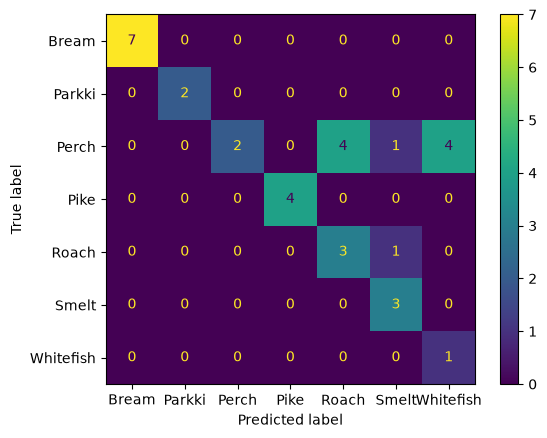

In [69]:
#Confusion Matrix :
cm = metrics.confusion_matrix(y_test , y_preds , labels = log_clf.classes_)
disp = metrics.ConfusionMatrixDisplay(cm , display_labels = log_clf.classes_)
disp.plot()

In [70]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(log_clf, df.drop(columns=['species']), df['species'], cv=5)
print("5-Fold CV Scores:", cv_scores)
print(f"Mean Accuracy: {cv_scores.mean():.4f}")

5-Fold CV Scores: [0.46875    0.625      0.71875    0.75       0.51612903]
Mean Accuracy: 0.6157


In [71]:
def make_results_log(model_name, y_test , y_preds):
    accuracy  = metrics.accuracy_score(y_test, y_preds)
    precision = metrics.precision_score(y_test, y_preds, average='weighted')
    recall   = metrics.recall_score(y_test, y_preds, average='weighted')
    f1 = metrics.f1_score(y_test, y_preds, average='weighted')
    # Create table of results
    table = pd.DataFrame({'Model': [model_name],
                        'Accuracy': [accuracy] ,
                        'Precision': [precision],
                        'Recall': [recall],
                        'F1': [f1]
                         }
                        )
  
    return table

In [72]:
print(f"{metrics.classification_report(y_test , y_preds)}")

              precision    recall  f1-score   support

       Bream       1.00      1.00      1.00         7
      Parkki       1.00      1.00      1.00         2
       Perch       1.00      0.18      0.31        11
        Pike       1.00      1.00      1.00         4
       Roach       0.43      0.75      0.55         4
       Smelt       0.60      1.00      0.75         3
   Whitefish       0.20      1.00      0.33         1

    accuracy                           0.69        32
   macro avg       0.75      0.85      0.71        32
weighted avg       0.87      0.69      0.66        32



In [20]:
results = make_results_log("Logistic Regression" , y_test , y_preds)

D:\01_Uni_Apps\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [21]:
results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.8125,0.708036,0.8125,0.751563


# Model 2 : Tuned Decision Tree

In [63]:
#Parameters : 
tree_para = {'max_depth':[4,5,6,7,8,9,10,11,12,15,20,30,40,50],
             'min_samples_leaf': [2, 5, 10, 20, 50]}

In [64]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_weighted',  
    'recall': 'recall_weighted',        
    'f1': 'f1_weighted'                
}

In [65]:
tuned_dt = DecisionTreeClassifier(random_state = 42)

In [ ]:
dt_clf = GridSearchCV(tuned_dt, 
                   tree_para, 
                   scoring = scoring, 
                   cv=5, 
                   refit="f1")
#Fit the model
#dt_clf.fit(x_train, y_train)

In [26]:
import pickle
path = '02_Models/'
#with open(path + '01_Tuned_Decision_Tree_model.pkl', 'wb') as file:
#   pickle.dump(dt_clf, file)
with open(path + '01_Tuned_Decision_Tree_model.pkl', 'rb') as file :
    dt_clf = pickle.load(file)

In [27]:
dt_clf.best_estimator_

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [28]:
print(f"Best Average F1 Score of Tuned DT : {dt_clf.best_score_}")

Best Average F1 Score of Tuned DT : 0.6956109890109891


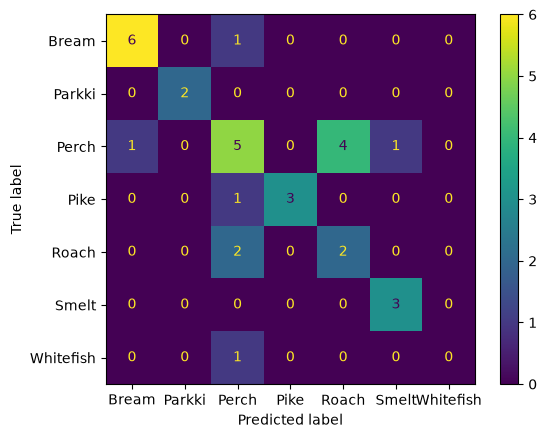

In [29]:
#Confusion Matrix :
y_preds = dt_clf.predict(x_test)
cm = metrics.confusion_matrix(y_test , y_preds , labels = dt_clf.classes_)
disp = metrics.ConfusionMatrixDisplay(cm , display_labels = dt_clf.classes_)
disp.plot()

In [30]:
def make_results(model_name, model_object):

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(mean f1 score)
    best_estimator_results = cv_results.iloc[cv_results['mean_test_f1'].idxmax(), :]

    # Extract accuracy, precision, recall, and f1 score from that row
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy
  
    # Create table of results
    table = pd.DataFrame({'Model': [model_name],
                        'Accuracy': [accuracy] ,
                        'Precision': [precision],
                        'Recall': [recall],
                        'F1': [f1]
                         }
                        )
  
    return table

In [31]:
results_v2 = make_results("Tuned Decision Tree" , dt_clf)
results_v2

,Model,Accuracy,Precision,Recall,F1
0,Tuned Decision Tree,0.716,0.708174,0.716,0.695611


In [32]:
final_results = pd.concat([results , results_v2] , axis = 0).reset_index(drop = True)

In [33]:
final_results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.8125,0.708036,0.8125,0.751563
1,Tuned Decision Tree,0.7160,0.708174,0.7160,0.695611


# Model 3 : Tuned Random Forest

In [34]:
#Define Parameters :
params_rf = {
    'n_estimators' : [50 , 100 , 150] ,
    'max_depth' : [None , 2 , 4 , 8] ,
    'min_samples_split' : [2 , 5 , 10] ,
    'min_samples_leaf' : [2 , 5] ,
    'max_features' : [None , 'sqrt' , 'log2']
}


In [35]:
rf = RandomForestClassifier(random_state = 40 )

In [36]:
rf_clf = GridSearchCV(
    estimator=rf,
    param_grid=params_rf,
    scoring=scoring,
    cv=5,
    refit='f1',
    n_jobs=-1,
    verbose=0
)
#rf_clf.fit(x_train , y_train)

In [37]:
import pickle
path = '02_Models/'
#with open(path + '02_Tuned_Random_Forest_model.pkl', 'wb') as file:
#    pickle.dump(rf_clf, file)
with open(path + '02_Tuned_Random_Forest_model.pkl', 'rb') as file :
    rf_clf = pickle.load(file)



In [38]:
rf_clf.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",40
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [39]:
print(f"Best Average F1 Score of Tuned Randome Forest : {rf_clf.best_score_}")

Best Average F1 Score of Tuned Randome Forest : 0.7281950937950938


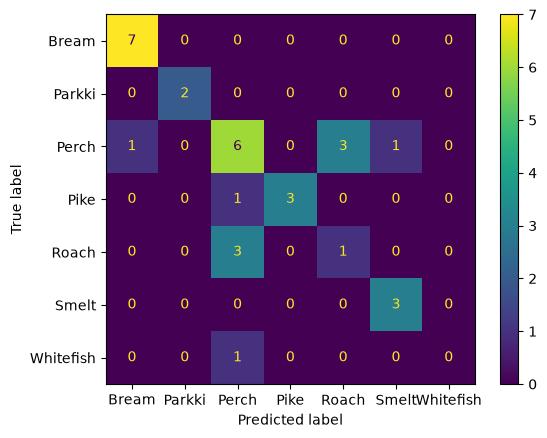

In [40]:
#Confusion Matrix :
y_preds = rf_clf.predict(x_test)
cm = metrics.confusion_matrix(y_test , y_preds , labels = rf_clf.classes_)
disp = metrics.ConfusionMatrixDisplay(cm , display_labels = rf_clf.classes_)
disp.plot()

In [41]:
results_v2 = make_results("Tuned Random Forest" , rf_clf)

In [42]:
final_results = pd.concat([final_results , results_v2] , axis = 0).reset_index(drop = True)
final_results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.812500,0.708036,0.812500,0.751563
1,Tuned Decision Tree,0.716000,0.708174,0.716000,0.695611
2,Tuned Random Forest,0.747077,0.731583,0.747077,0.728195


# Model 4 : XG Boost

In [43]:
#Encode the Target Variable for Y , Since XGB Doesn't handle strings automatically like Scikit-Learn :
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_en = le.fit_transform(y_train)
y_test_en = le.transform(y_test)

In [44]:
#Build Model :
xgb = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

In [45]:
#Define Params : 
param_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 6],
    'subsample': [0.8, 1.0]
}

In [46]:
%%time
xgb_clf = GridSearchCV(
    xgb ,
    param_xgb ,
    scoring = scoring ,
    refit = 'f1' ,
    cv = 5 ,
    n_jobs = -1 ,
    verbose = 0
)
#xgb_clf.fit(x_train , y_train_en)

CPU times: total: 0 ns
Wall time: 38.4 μs


In [ ]:
#with open(path + "03_Tuned_XG_Boost_Model.pkl" , "wb") as file :
#    pickle.dump(xgb_clf , file)

In [47]:
with open(path + "03_Tuned_XG_Boost_Model.pkl" , "rb") as file :
    xgb_clf = pickle.load(file)

C:\Users\M Abdullah\AppData\Local\Temp\ipykernel_11004\3357552408.py:2: UserWarning: [20:41:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\gbm\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  xgb_clf = pickle.load(file)


In [48]:
xgb_clf.best_estimator_

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) 

In [49]:
print(f"Best Average F1 Score of tuned Gradient Boosting is : {xgb_clf.best_score_}")

Best Average F1 Score of tuned Gradient Boosting is : 0.7154291369449265


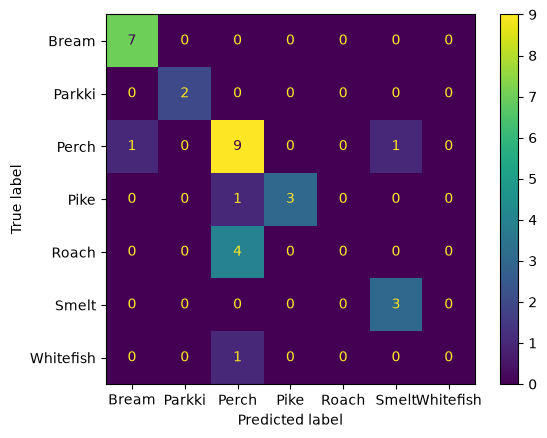

In [50]:
#Confusion Matrix :
y_preds = xgb_clf.predict(x_test)
cm = metrics.confusion_matrix(y_test_en , y_preds , labels = xgb_clf.classes_)
disp = metrics.ConfusionMatrixDisplay(cm , display_labels = le.classes_)
disp.plot()

In [51]:
results_v2 = make_results("Tuned XGBoost" , xgb_clf)

In [52]:
final_results = pd.concat([final_results , results_v2] , axis = 0).reset_index(drop = True)
final_results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.812500,0.708036,0.812500,0.751563
1,Tuned Decision Tree,0.716000,0.708174,0.716000,0.695611
2,Tuned Random Forest,0.747077,0.731583,0.747077,0.728195
3,Tuned XGBoost,0.740000,0.710472,0.740000,0.715429


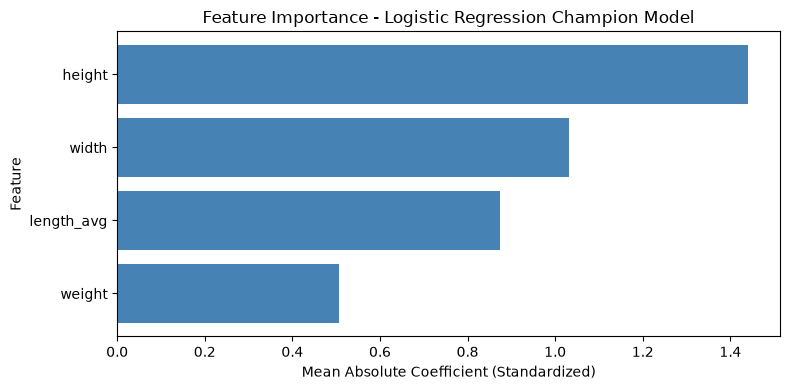

   Feature  Importance
    height    1.441255
     width    1.030990
length_avg    0.873786
    weight    0.506558


In [76]:
#Lets plot feature importance for champion model :
lr_model = log_clf.named_steps['classifier']
feature_names = log_clf.named_steps['preprocessor'].get_feature_names_out()
feature_names = [col.replace('num__', '') for col in feature_names]
avg_importance = np.mean(np.abs(lr_model.coef_), axis=0)
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': avg_importance
}).sort_values(by='Importance', ascending=True)
plt.figure(figsize=(8, 4))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Mean Absolute Coefficient (Standardized)')
plt.ylabel('Feature')
plt.title('Feature Importance - Logistic Regression Champion Model')
plt.tight_layout()
plt.show()
print(importance_df.sort_values(by='Importance', ascending=False).to_string(index=False))


### Final Model Selection: Champion Model

After testing all four models—**Logistic Regression**, **Decision Tree**, **Random Forest**, and **XGBoost**—the clear winner is **Logistic Regression**.

* **Best Performance:** It achieved the highest scores across **Accuracy**, **Recall**, and **F1-Score** compared to the other models.
---

> **Champion Model: Logistic Regression**
> Because it has the highest overall scores and generalizes best on unseen test data, **Logistic Regression** is chosen as the final champion model.